<a href="https://colab.research.google.com/github/OPCIO0568/2026-1_CV/blob/main/HW%232-8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

원본 이미지


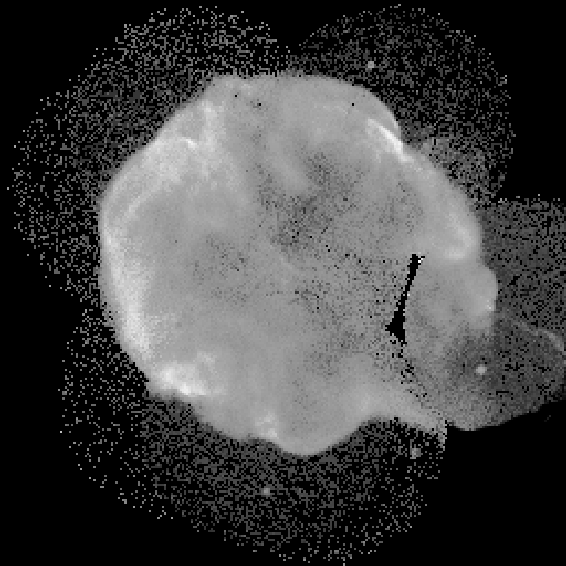

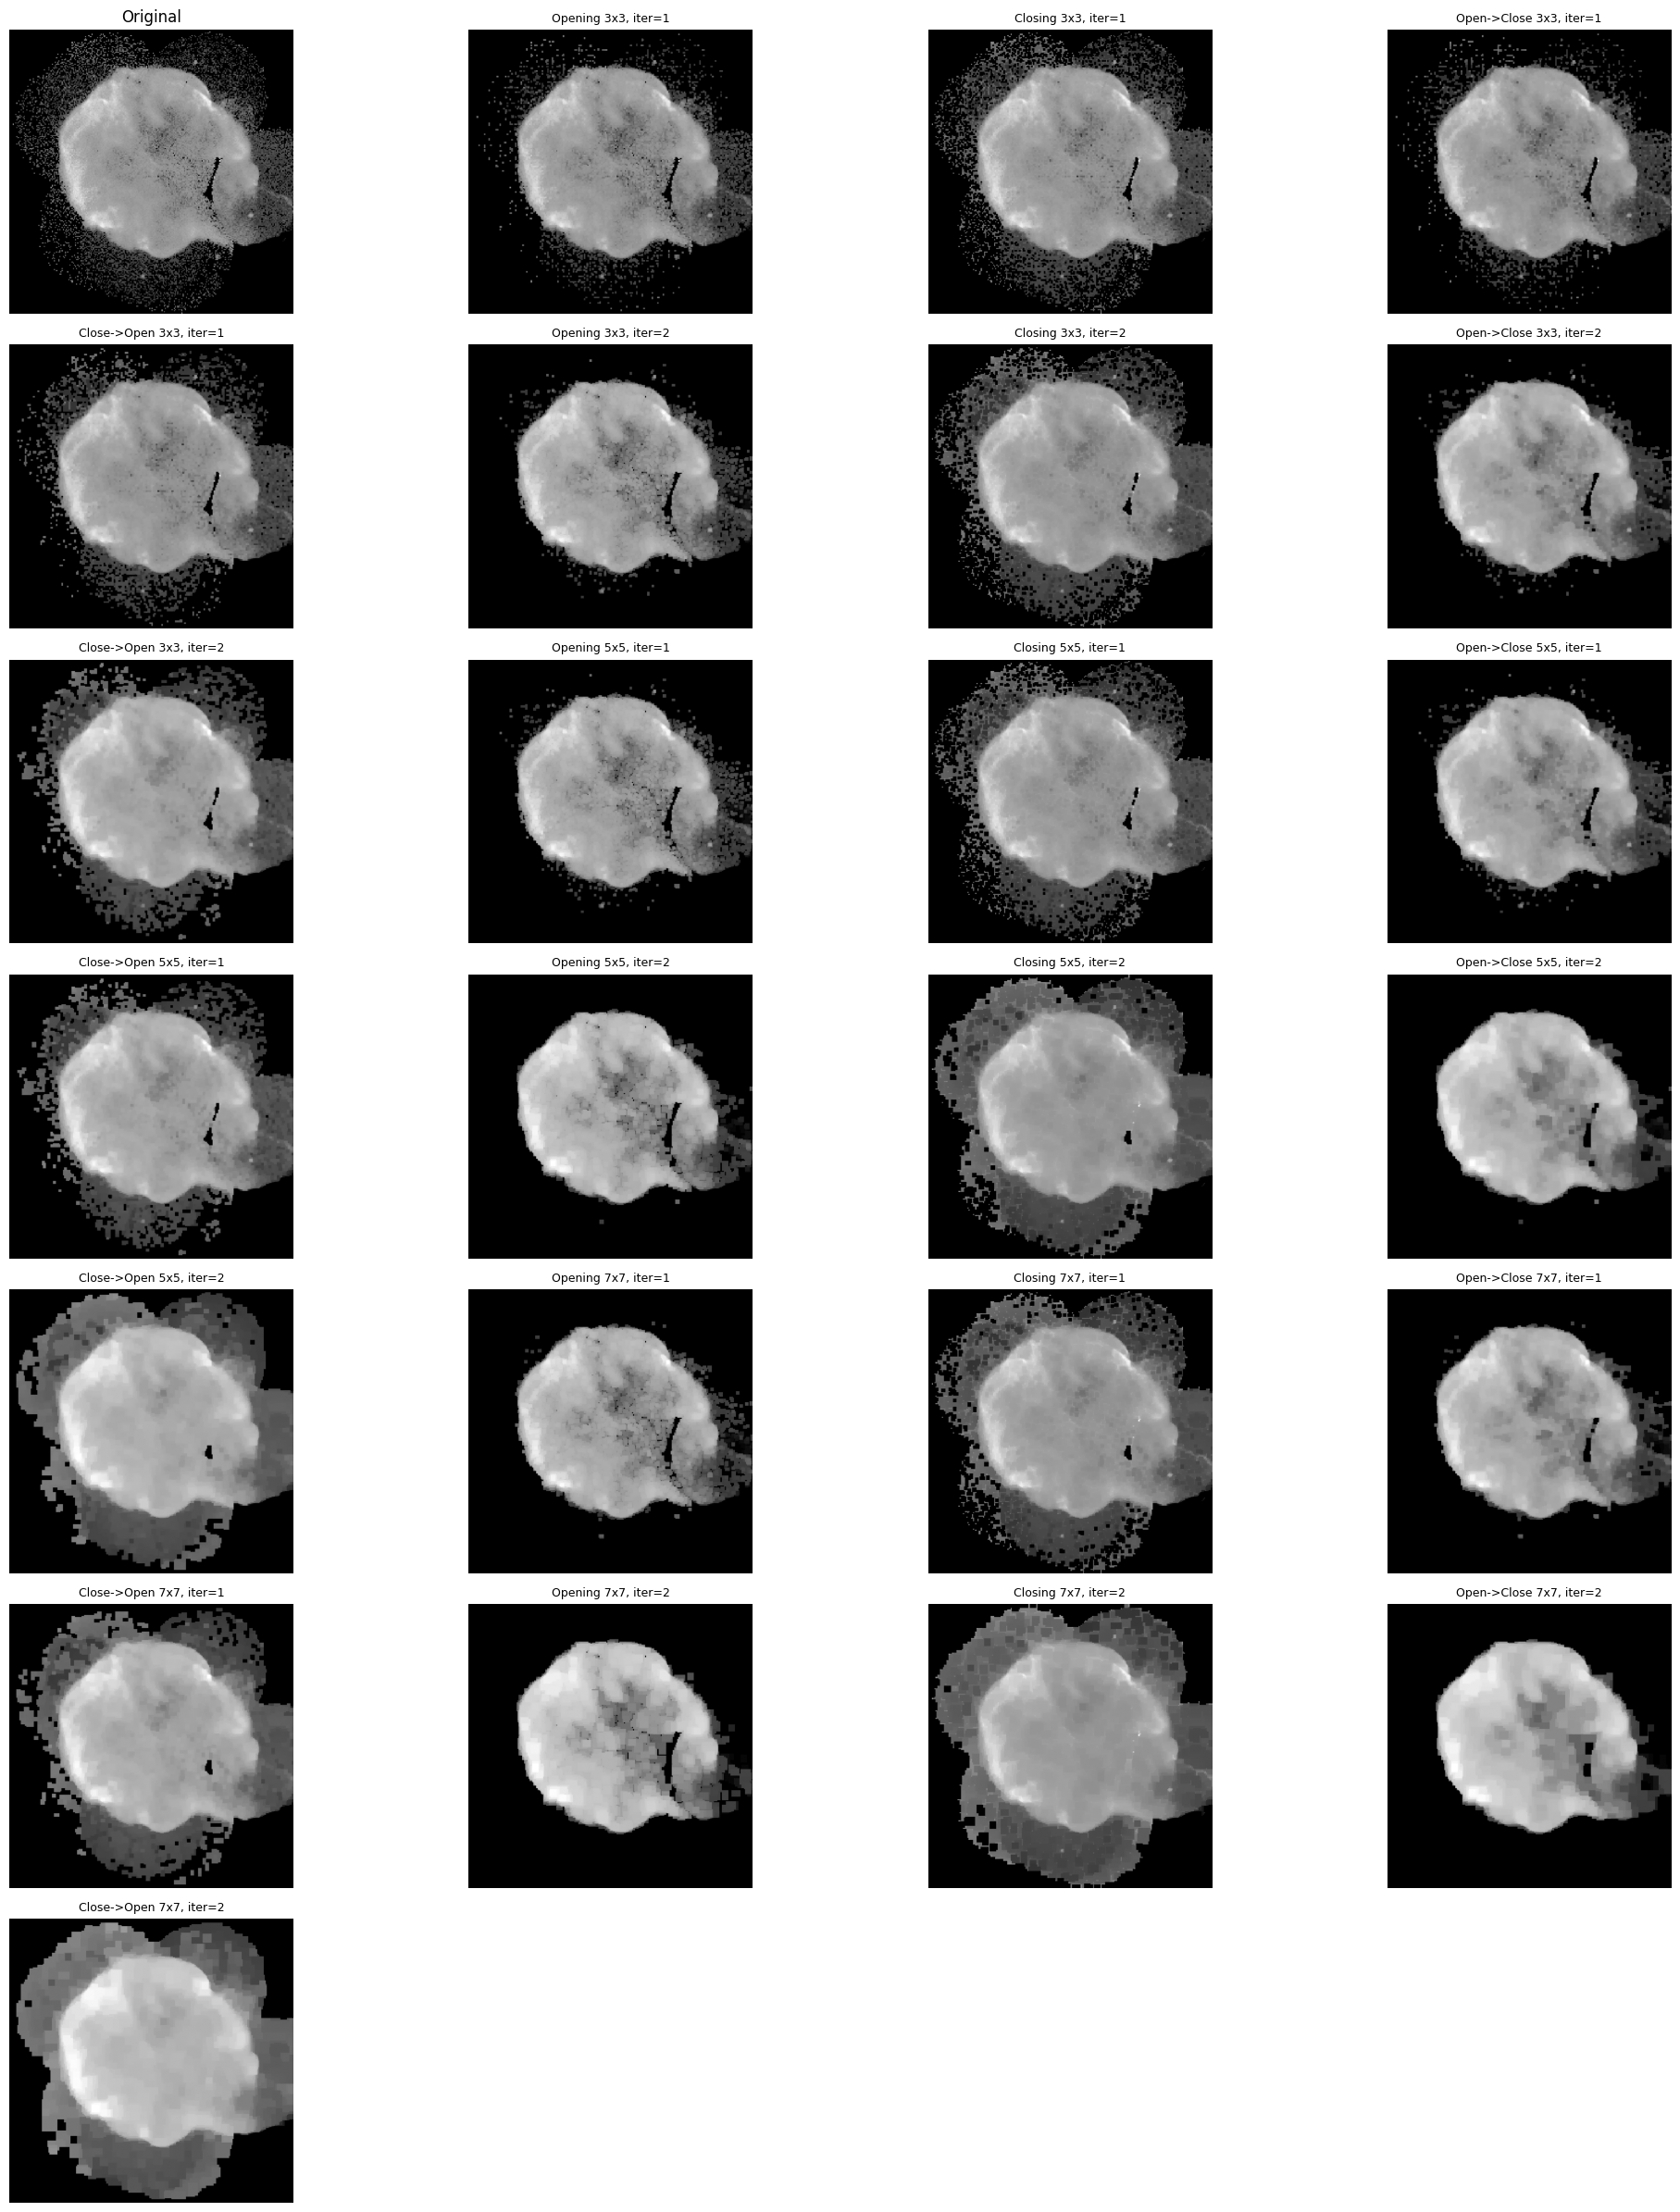

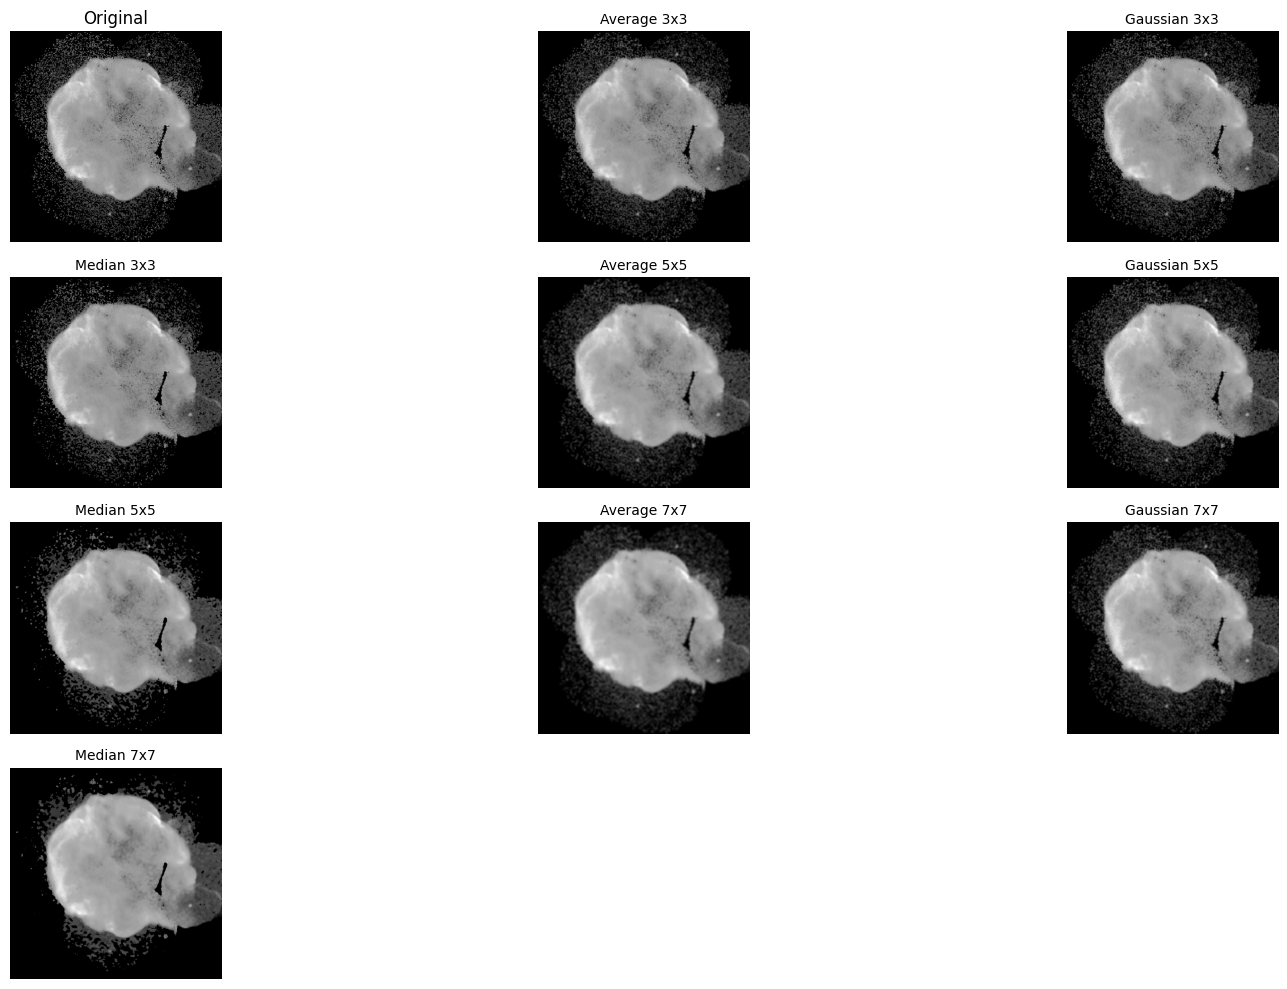

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

# -------------------------------
# 1) 이미지 업로드
# -------------------------------

img = cv2.imread('/content/Fig0938(a)(cygnusloop_Xray_original).tif', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("이미지를 불러오지 못했습니다.")

print("원본 이미지")
cv2_imshow(img)

# -------------------------------
# 2) Morphological Smoothing
# -------------------------------
kernel_sizes = [3, 5, 7]
iterations_list = [1, 2]

morph_results = []
morph_titles = []

for k in kernel_sizes:
    kernel = np.ones((k, k), np.uint8)

    for it in iterations_list:
        opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel, iterations=it)
        closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=it)

        opening_closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=it)
        closing_opening = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel, iterations=it)

        morph_results.extend([opening, closing, opening_closing, closing_opening])
        morph_titles.extend([
            f'Opening {k}x{k}, iter={it}',
            f'Closing {k}x{k}, iter={it}',
            f'Open->Close {k}x{k}, iter={it}',
            f'Close->Open {k}x{k}, iter={it}'
        ])

# -------------------------------
# 3) Smoothing Filter
# -------------------------------
filter_sizes = [3, 5, 7]

smooth_results = []
smooth_titles = []

for k in filter_sizes:
    # Average filter
    avg = cv2.blur(img, (k, k))
    smooth_results.append(avg)
    smooth_titles.append(f'Average {k}x{k}')

    # Gaussian filter
    gauss = cv2.GaussianBlur(img, (k, k), 0)
    smooth_results.append(gauss)
    smooth_titles.append(f'Gaussian {k}x{k}')

    # Median filter
    median = cv2.medianBlur(img, k)
    smooth_results.append(median)
    smooth_titles.append(f'Median {k}x{k}')

# -------------------------------
# 4) Morphological results 출력
# -------------------------------
plt.figure(figsize=(20, 24))

plt.subplot(7, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, (res, title) in enumerate(zip(morph_results, morph_titles), start=2):
    plt.subplot(7, 4, i)
    plt.imshow(res, cmap='gray')
    plt.title(title, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

# -------------------------------
# 5) Smoothing Filter results 출력
# -------------------------------
plt.figure(figsize=(16, 10))

plt.subplot(4, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, (res, title) in enumerate(zip(smooth_results, smooth_titles), start=2):
    plt.subplot(4, 3, i)
    plt.imshow(res, cmap='gray')
    plt.title(title, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()